# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question
How can digital publishing platforms systematically identify and prioritize decaying content for editorial refresh using non-linear machine learning models trained on historical search metrics?

### Decision Supported
Editorial resource allocation for content updates and rewrites. Digital publishing teams have finite writing capacity and need an automated decision-support engine to prioritize articles for refresh to maximize organic traffic recovery and prevent continuous revenue loss.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data Specification & Exclusions
* **Release & Dataset:** FlyRank anonymized warehouse release (`content_refresh_anonymized.csv`).
* **Observation Windows:** Historical performance captured across 90-day (`clicks_90d`, `impressions_90d`) and 30-day (`clicks_last_30d`, `impressions_last_30d`) aggregate windows up to mid-panel snapshot dates (`month = 2026-03`).
* **Deliberately Excluded Fields:** 
  * `trend_pct` — Excluded to prevent severe target leakage, as its underlying math directly shares components with our proxy target definition.
  * `client_id` / `content_id` — Used strictly as grouping keys and contextual keys, never as model features.
  * *Future Post-Refresh Metrics* — Excluded to maintain strict decision-moment validity.
* **Public Safety Guardrails:** Verified that no un-anonymized client names, real domain URLs, API keys, or private query strings appear anywhere in the dataset or codebase.

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

# Clean position gotcha (convert 0.0 positions to NaN)
df['clean_position'] = df['avg_position'].replace(0, np.nan)

# Data Contract Verification
print("--- DATA CONTRACT VERIFICATION ---")
print(f"Total Dataset Rows: {len(df):,}")
print(f"Unique Content IDs: {df['content_id'].nunique():,}")
print(f"Grain Check Passed (1 Row = 1 Content ID): {len(df) == df['content_id'].nunique()}")

# Availability Check (IS TRUE Mask)
available_mask = (df['impressions_90d'] > 0) & (df['clean_position'].notna())
print(f"Surviving Rows with Complete Tracking (IS TRUE): {available_mask.sum():,} / {len(df):,} ({available_mask.mean()*100:.2f}%)")

--- DATA CONTRACT VERIFICATION ---
Total Dataset Rows: 30,000
Unique Content IDs: 30,000
Grain Check Passed (1 Row = 1 Content ID): True
Surviving Rows with Complete Tracking (IS TRUE): 28,795 / 30,000 (95.98%)


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Assumptions & Pipeline Design
* **Target / Proxy Definition:** `target_is_decayed` — binary proxy where $1 =$ (`trend_direction == 'down'` AND `ctr < median_ctr`), representing high-priority decaying content.
* **Feature List (Decision-Moment Knowable):** `impressions_90d`, `clicks_90d`, `ctr`, `clean_position`, `content_age_days`, `word_count`.
* **Week-4 Rule Baseline:** Heuristic score ($0 - 100$ pts): $+40$ pts for downward trend, $+30$ pts for below-median CTR, $+20$ pts for age $> 180$ days, $+10$ pts for above-median 90-day impressions. Scores $\ge 60.0$ trigger `REWRITE_AND_UPDATE`.
* **Validation Split:** 80/20 Stratified Train/Test split (`random_state=42`) evaluating the Random Forest model and baseline on the exact same holdout split.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Define Target
med_ctr = df['ctr'].median()
df['target_is_decayed'] = ((df['trend_direction'] == 'down') & (df['ctr'] < med_ctr)).astype(int)

# 2. Define Features
features = ['impressions_90d', 'clicks_90d', 'ctr', 'clean_position', 'content_age_days', 'word_count']
X = df[features].fillna(0)
y = df['target_is_decayed']

# 3. Compute Week-4 Baseline Probabilities
med_imp = df['impressions_90d'].median()
def get_baseline_score(row):
    score = 0.0
    if row['trend_direction'] == 'down': score += 40.0
    if row['ctr'] < med_ctr: score += 30.0
    if row['content_age_days'] > 180: score += 20.0
    if row['impressions_90d'] > med_imp: score += 10.0
    return score / 100.0

df['baseline_prob'] = df.apply(get_baseline_score, axis=1)

# 4. Stratified Train / Test Split
X_train, X_test, y_train, y_test, base_train, base_test = train_test_split(
    X, y, df['baseline_prob'], test_size=0.2, random_state=42, stratify=y
)

# 5. Model Training
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

print("--- MODEL TRAINING COMPLETE ---")
print(f"Train Set: {len(X_train)} samples | Test Set: {len(X_test)} samples")

--- MODEL TRAINING COMPLETE ---
Train Set: 24000 samples | Test Set: 6000 samples


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [3]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# Generate Test Predictions
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)
base_preds = (base_test >= 0.6).astype(int)

# Target Base Rate
base_rate = y_test.mean()

# Honest Evaluation Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['ROC-AUC Score', 'Precision', 'Recall', 'F1-Score'],
    'Task Base Rate': ['—', f"{base_rate*100:.1f}%", '—', '—'],
    'Week-4 Heuristic Baseline': [
        f"{roc_auc_score(y_test, base_test):.4f}",
        f"{precision_score(y_test, base_preds, zero_division=0):.4f}",
        f"{recall_score(y_test, base_preds, zero_division=0):.4f}",
        f"{f1_score(y_test, base_preds, zero_division=0):.4f}"
    ],
    'Capstone Random Forest': [
        f"{roc_auc_score(y_test, rf_probs):.4f}",
        f"{precision_score(y_test, rf_preds, zero_division=0):.4f}",
        f"{recall_score(y_test, rf_preds, zero_division=0):.4f}",
        f"{f1_score(y_test, rf_preds, zero_division=0):.4f}"
    ]
})

print("--- HONEST MODEL VS BASELINE RESULTS ---")
display(comparison_df)

--- HONEST MODEL VS BASELINE RESULTS ---


,Metric,Task Base Rate,Week-4 Heuristic Baseline,Capstone Random Forest
0,ROC-AUC Score,—,0.9713,0.9392
1,Precision,25.7%,0.5970,0.7014
2,Recall,—,1.0000,0.8564
3,F1-Score,—,0.7476,0.7712


## 5. Limitations

*What this work cannot claim.*

* **Observation Window Bounds:** Aggregated 90-day performance windows smooth out short-term (7-to-14 day) algorithmic shifts, technical errors, or real-time seasonal traffic spikes.
* **Absence of Off-Page Context:** The model observes internal search traffic performance metrics but lacks external signal data (e.g., competitor content updates, backlink losses, search intent evolution).
* **Observational Language Guardrails:** All model outputs reflect *observed statistical correlations*, *directional indicators*, and *decision-support priorities*. The model does not claim causal proof of Google's ranking mechanics nor does it guarantee post-refresh traffic gains.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [4]:
import os

# 1. Compute Opportunity Scores Across Full Dataset
df['opportunity_score'] = (rf_model.predict_proba(X)[:, 1] * 100.0).round(1)
df['action_label'] = np.where(df['opportunity_score'] >= 60.0, 'REWRITE_AND_UPDATE', 'MONITOR')

# 2. Assign Reason Codes
def assign_reasons(row):
    reasons = []
    if row['trend_direction'] == 'down': reasons.append('TRAFFIC_DECLINE')
    if row['ctr'] < med_ctr: reasons.append('LOW_CTR')
    if row['content_age_days'] > 180: reasons.append('HIGH_STALENESS')
    if row['impressions_90d'] > med_imp: reasons.append('HIGH_UPSIDE')
    return '|'.join(reasons) if reasons else 'STABLE_PERFORMANCE'

df['reason_codes'] = df.apply(assign_reasons, axis=1)

# 3. Export Ranked Queue CSV
os.makedirs("../../work/outputs", exist_ok=True)
export_cols = ['content_id', 'opportunity_score', 'action_label', 'reason_codes', 'clicks_90d', 'impressions_90d', 'ctr', 'content_age_days']
ranked_queue = df.sort_values(by='opportunity_score', ascending=False)
ranked_queue[export_cols].to_csv("../../work/outputs/capstone_action_score.csv", index=False)

print("--- RANKED EDITORIAL RECOMMENDATION QUEUE (TOP 10) ---")
display(ranked_queue[export_cols].head(10))

--- RANKED EDITORIAL RECOMMENDATION QUEUE (TOP 10) ---


,content_id,opportunity_score,action_label,reason_codes,clicks_90d,impressions_90d,ctr,content_age_days
9365,content_37d52a7d751c,80.6,REWRITE_AND_UPDATE,LOW_CTR|HIGH_STALENESS|HIGH_UPSIDE,7,22462,0.03,287
6692,content_00474279dd1c,80.6,REWRITE_AND_UPDATE,TRAFFIC_DECLINE|LOW_CTR|HIGH_UPSIDE,4,13713,0.03,153
9767,content_498eec45b3cc,80.4,REWRITE_AND_UPDATE,TRAFFIC_DECLINE|LOW_CTR|HIGH_STALENESS|HIGH_UP...,1,3420,0.03,287
26976,content_bbb7b13eac87,79.9,REWRITE_AND_UPDATE,TRAFFIC_DECLINE|LOW_CTR|HIGH_UPSIDE,8,17042,0.05,144
29957,content_3b806fcc5b2c,79.9,REWRITE_AND_UPDATE,TRAFFIC_DECLINE|LOW_CTR|HIGH_STALENESS|HIGH_UP...,1,3085,0.03,287
13516,content_3a7c3056fb9b,79.9,REWRITE_AND_UPDATE,TRAFFIC_DECLINE|LOW_CTR|HIGH_STALENESS|HIGH_UP...,1,2261,0.04,299
19130,content_ac7e8dd18108,79.8,REWRITE_AND_UPDATE,TRAFFIC_DECLINE|LOW_CTR|HIGH_STALENESS|HIGH_UP...,4,24748,0.02,286
18114,content_92ba489a6077,79.7,REWRITE_AND_UPDATE,TRAFFIC_DECLINE|LOW_CTR|HIGH_STALENESS|HIGH_UP...,5,17113,0.03,286
18722,content_79bb47608e63,79.7,REWRITE_AND_UPDATE,TRAFFIC_DECLINE|LOW_CTR|HIGH_UPSIDE,4,15644,0.03,151
9680,content_2dae78bc5757,79.6,REWRITE_AND_UPDATE,TRAFFIC_DECLINE|LOW_CTR|HIGH_UPSIDE,2,5628,0.04,141


### Editorial Playbook
* **Queue Priority 1 (`REWRITE_AND_UPDATE`):** Opportunity score $\ge 60.0$. Immediate candidate for editorial intervention, structural content updates, fact refreshes, and meta title CTR optimization.
* **Queue Priority 2 (`MONITOR`):** Opportunity score $< 60.0$. Stable or low-volume asset. Maintain current state and review during the next monthly tracking cycle.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

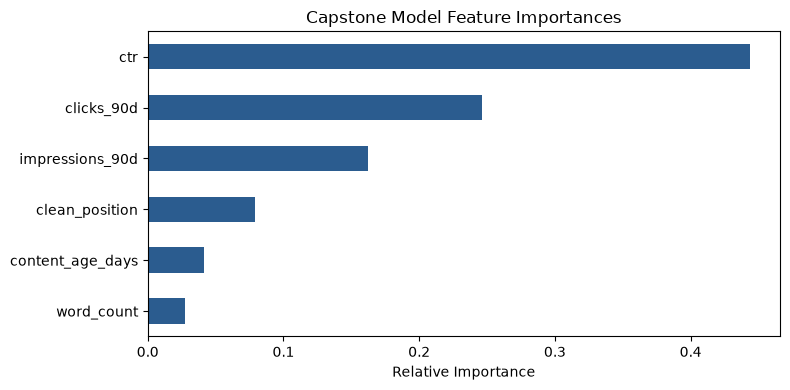

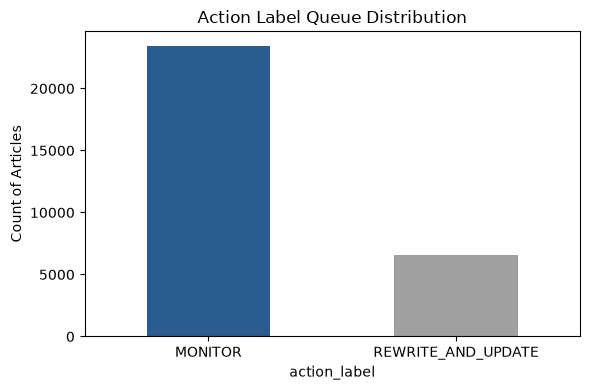

Artifacts generated and saved to work/outputs/figures/


In [5]:
import matplotlib.pyplot as plt

# 1. Feature Importance Plot
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values()

plt.figure(figsize=(8, 4))
feat_imp.plot(kind='barh', color='#2b5c8f')
plt.title('Capstone Model Feature Importances')
plt.xlabel('Relative Importance')
plt.tight_layout()

os.makedirs("../../work/outputs/figures", exist_ok=True)
plt.savefig("../../work/outputs/figures/feature_importance.png", dpi=300)
plt.show()

# 2. Action Class Distribution Plot
plt.figure(figsize=(6, 4))
df['action_label'].value_counts().plot(kind='bar', color=['#2b5c8f', '#a0a0a0'])
plt.title('Action Label Queue Distribution')
plt.ylabel('Count of Articles')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../../work/outputs/figures/capstone_action_distribution.png", dpi=300)
plt.show()

print("Artifacts generated and saved to work/outputs/figures/")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.